Simple example of single-window 4D-Var assimilation on the Lorenz-96 system.

The system state is composed of $N$ variables $x_1, ..., x_N$ with periodic boundaries (i.e. $x_{N+1} = x_{1}, x_{0} = x_N, x_{-1} = x_{N-1}$).

For $i=1, ..., N$, its evolution is described by:

$\frac{dx_i}{dt} = (x_{i+1} - x_{i-2}) x_{i-1} - x_i + F$

We will use the most common choices $N=40$ and $F=8$.

We use single-window strong-constraint and single-window weak-constraint 4D-Var.

In [1]:
import os
import torch
from matplotlib import pyplot as plt
from time import time
from tensordict import TensorDict
from mdml_sim.lorenz96 import L96Simulator
os.chdir('..')
from adda.variational.strong_constraint_4dvar import sc4dvar_single_window
from adda.variational.weak_constraint_4dvar import wc4dvar_single_window
from adda.system.state import State
from adda.observation.operators import random_sparse_noisy_obs
from adda.util.initialization import naive_initialization
from adda.util.visualization import show_1dseqimg
from adda.probability.distributions import DiagonalGaussian

# Generate groundtruth time series and observations

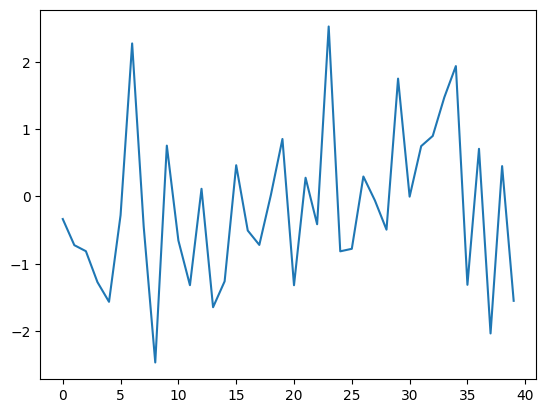

In [2]:
# Define a target initial state
n_variables = 40 # N = 40
initial_state = State(torch.randn(1, 1, n_variables))  # (batch, time, n_variables)
plt.plot(initial_state.fields['x'].squeeze())

torch.Size([1200, 40])


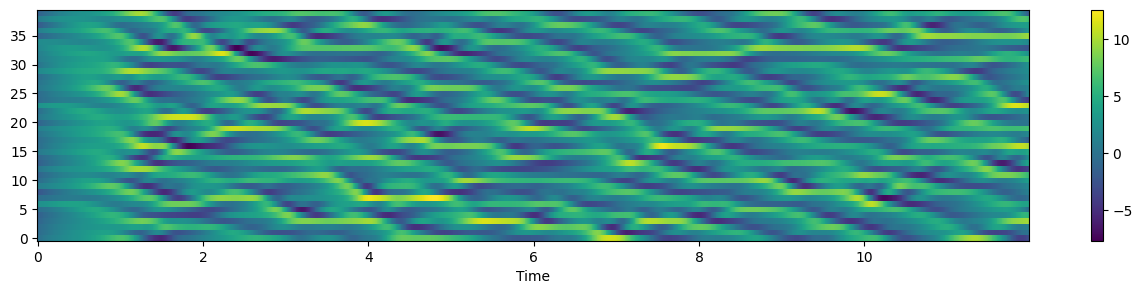

In [3]:
# Generate a time series from the defined initial_condition using our L96 simulator
forward_operator = L96Simulator(forcing=8.0) # F = 8
ts_length = 1200
time_step = 0.01 # one time step = 0.01 second
forecast_steps = torch.arange(0, ts_length * time_step, time_step)
ts = forward_operator.integrate(time=forecast_steps, state=initial_state.fields['x'].reshape(1, -1)).squeeze()

print(ts.shape)
show_1dseqimg(ts.T, dt=time_step, x_label="Time")

One can see that, for roughly the first second of the forecast, the state is less structured than during the remaining of the time series. This is due to the fact that our sampled initial condition was not taken from the actual stationary distribution of the L96 system. In order to make up for this issue, we will "burn" the first 2 seconds of the time series and actually perform our assimilation on the remaining 8 seconds of data only.

In [4]:
cutoff_time = 4
cutoff_index = int(cutoff_time / time_step)
true_ts = ts[cutoff_index:]
true_initial_state = true_ts[0]
forecast_steps = torch.arange(0, ts_length * time_step - cutoff_time, time_step)

true_ts = State(true_ts.reshape(1, -1, n_variables), time_axis=forecast_steps)

We now add some Gaussian noise and a binary mask on the true time series, in order to generate corresponding observations.

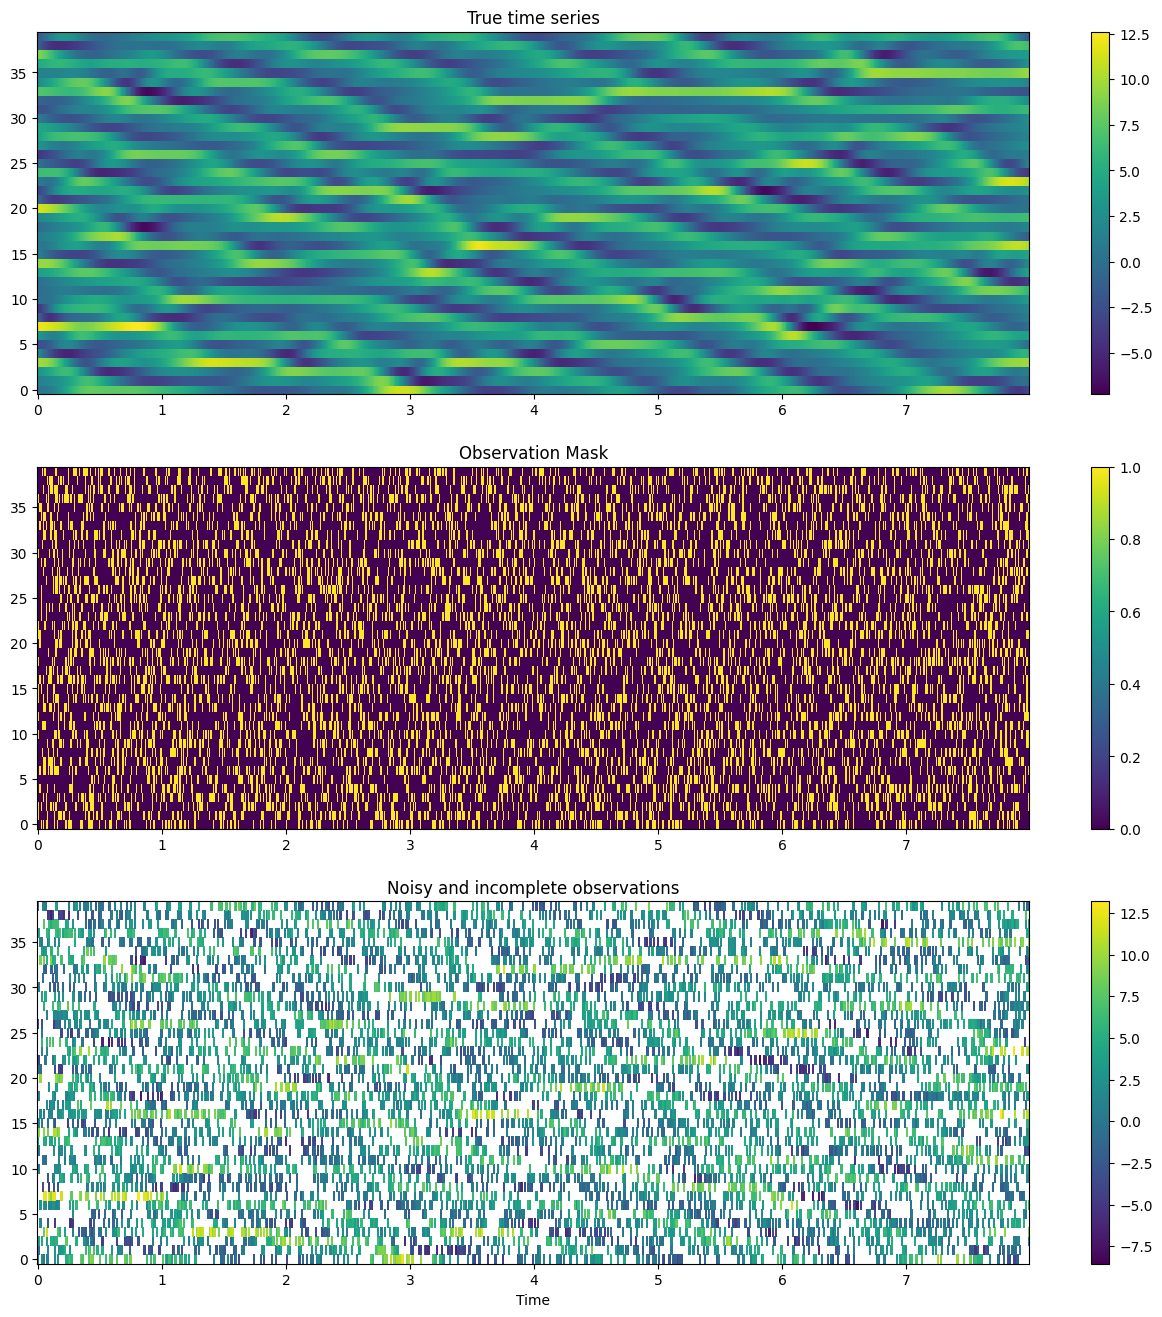

In [5]:
noise_amplitude = 1.0  # observation noise s.d.
p_obs = 0.25 # 75% of the variables are masked

groundtruth, obs_op, observations = random_sparse_noisy_obs(true_ts, noise_amplitude, p_obs)

valid_obs = observations.state.fields['x'][0].T
valid_obs[torch.logical_not(observations.mask.fields['x'][0].T)] = torch.nan

fig, ax = plt.subplots(3, 1, figsize=(16,16))

show_1dseqimg(true_ts.fields['x'][0].T, dt=time_step, ax=ax[0], title="True time series")
show_1dseqimg(observations.mask.fields['x'][0].T, dt=time_step, ax=ax[1], title="Observation Mask")
show_1dseqimg(valid_obs, dt=time_step, ax=ax[2], title="Noisy and incomplete observations", x_label="Time")

In [6]:
# we define a simple one-time-step function in order to fit the ADDA conventions
# In order to use the 4D-Var functions, you should always have a function like this taking the state, dt, dynamic_inputs and static_inputs

def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    "this time stepping function expects the input State x to have a single field called 'x'"
    B, T = x.fields.batch_size[:2]
    x_tensor = x.fields.reshape(-1)["x"]  # combine batch and time dimensions, leave others intact
    integrated = forward_operator.integrate(torch.arange(2) * dt, x_tensor)[:, 1]
    integrated = integrated.unsqueeze(0)  # re-add batch dimension
    new_fields = TensorDict(x=integrated, batch_size=(1, T))
    return State(new_fields, time_axis=x.time_axis + dt)  # return State object, advancing time

# Strong-constraint 4D-Var

Let us now implement the strong-constraint 4D-Var assimilation scheme to try to reconstruct the full time series from the noisy and incomplete observations.

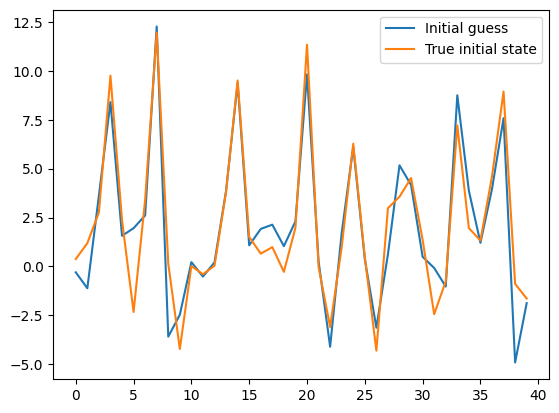

In [7]:
# we build an initial guess for the initial state, using the available observations
# We simply use the first available observation for each channel
initialization = naive_initialization(observations)  # state estimate for all time points
initialization = initialization[:, :1]  # first time point only

plt.plot(initialization.fields['x'].squeeze(), label='Initial guess')
plt.plot(true_initial_state, label='True initial state')
plt.legend()

In [8]:
n_obs_steps = 100 # we assimilate only on the earliest time steps, otherwise the optimization would be too unstable
time_window = (observations.state.time_axis[0], observations.state.time_axis[n_obs_steps])

obs_op_opt = obs_op.restrict_time_domain(*time_window)
observations_opt = observations.restrict_time_domain(*time_window)

print(obs_op.mask.fields)

TensorDict(
    fields={
        x: Tensor(shape=torch.Size([1, 800, 40]), device=cpu, dtype=torch.bool, is_shared=False)},
    batch_size=torch.Size([1, 800]),
    device=None,
    is_shared=False)


In [9]:
t0 = time()
assimilated_ic = sc4dvar_single_window(next_step_function, 
                                       observations_opt, 
                                       obs_op_opt, 
                                       initialization,  
                                       optimizer_pars={'lr': 1e-1})                                     
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

Total time for the 4D-Var optimization: 31.140671253204346 seconds


Here we display the assimilated initial state of the trajectory and compare it to the initialization of the 4D-Var optimization.

Initial guess MSE: 2.3627355098724365
Assimilated state MSE: 0.17150048911571503


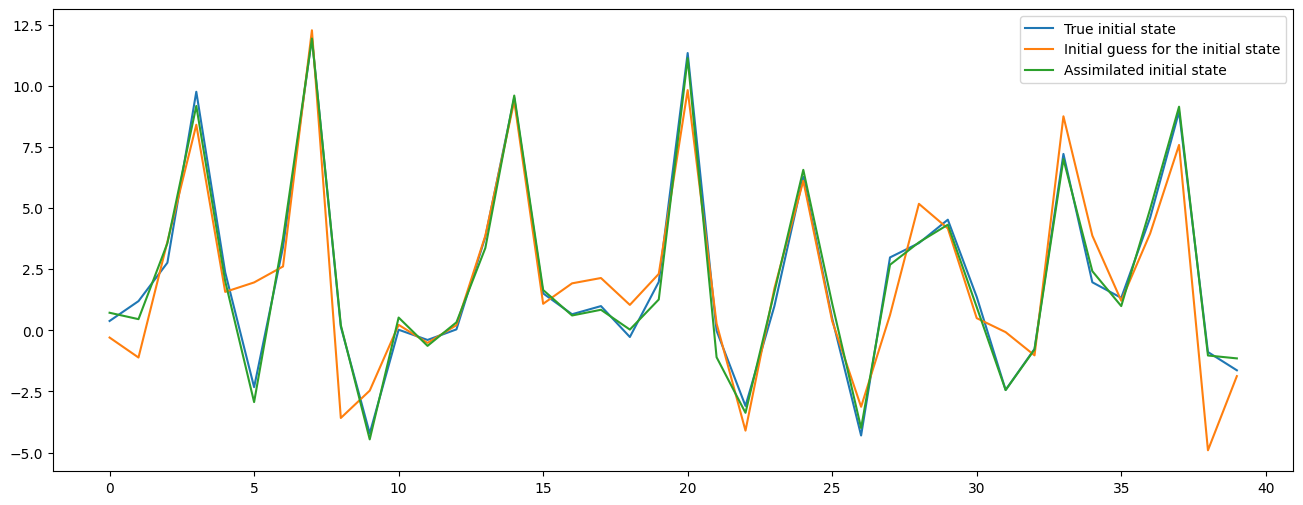

In [10]:
plt.figure(figsize=(16,6))
plt.plot(true_initial_state, label='True initial state')
plt.plot(initialization.fields['x'].squeeze(), label='Initial guess for the initial state')
plt.plot(assimilated_ic.fields['x'].squeeze().detach(), label='Assimilated initial state')
plt.legend()

MSE0 = torch.mean((initialization.fields['x'].squeeze() - true_initial_state) **2)
MSE = torch.mean((assimilated_ic.fields['x'].squeeze() - true_initial_state) **2)

print(f'Initial guess MSE: {MSE0}')
print(f'Assimilated state MSE: {MSE}')

We finally compute a rollout trajectory from the assimilated initial state and compare it to the groundtruth.

In [11]:
# rollout from assimilated state
assimilated_trajectory = forward_operator.integrate(time=forecast_steps, state=assimilated_ic.fields['x'][0]).squeeze().cpu().detach()

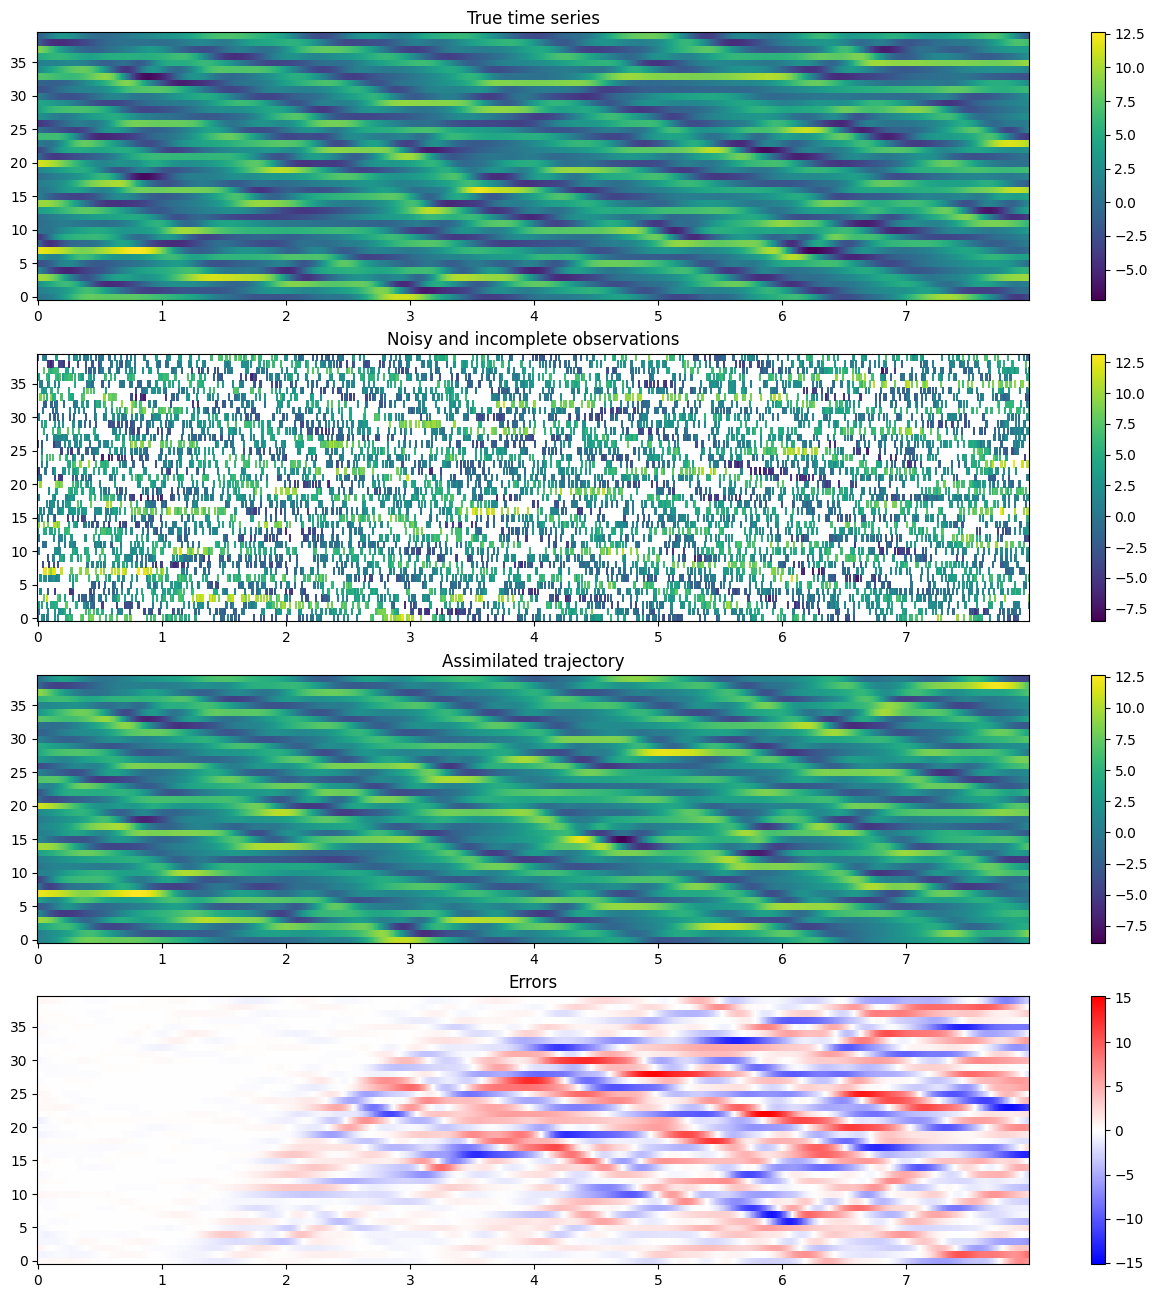

In [12]:
errors = (assimilated_trajectory - true_ts.fields['x'].squeeze())

fig, ax = plt.subplots(4, 1, figsize=(16,16))
show_1dseqimg(true_ts.fields['x'][0].T, dt=time_step, ax=ax[0], title="True time series")
show_1dseqimg(valid_obs, dt=time_step, ax=ax[1], title="Noisy and incomplete observations")
show_1dseqimg(assimilated_trajectory.T, dt=time_step, ax=ax[2], title="Assimilated trajectory")
show_1dseqimg(errors.T, dt=time_step, ax=ax[3], title="Errors", cmap="bwr", center_on_zero=True)

torch.Size([800])


Text(0, 0.5, 'RMSE')

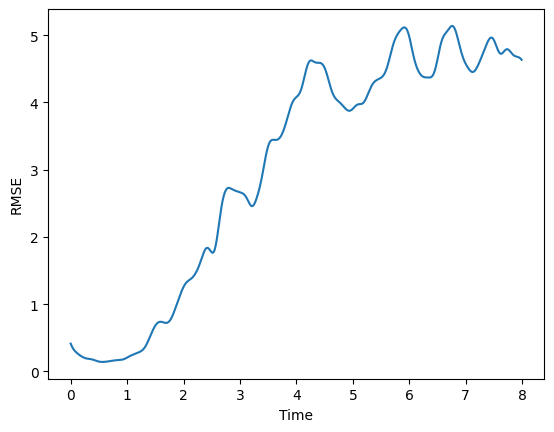

In [13]:
RMSE_over_time = torch.sqrt((errors ** 2).mean(dim=1))
print(RMSE_over_time.shape)

fig, ax = plt.subplots()
plt.plot(forecast_steps, RMSE_over_time)
ax.set_xlabel('Time')
ax.set_ylabel('RMSE')

After 2 to 3 seconds the RMSE explodes, which is to be expected for a chaotic system like Lorenz-96.

# Weak-constraint 4D-Var

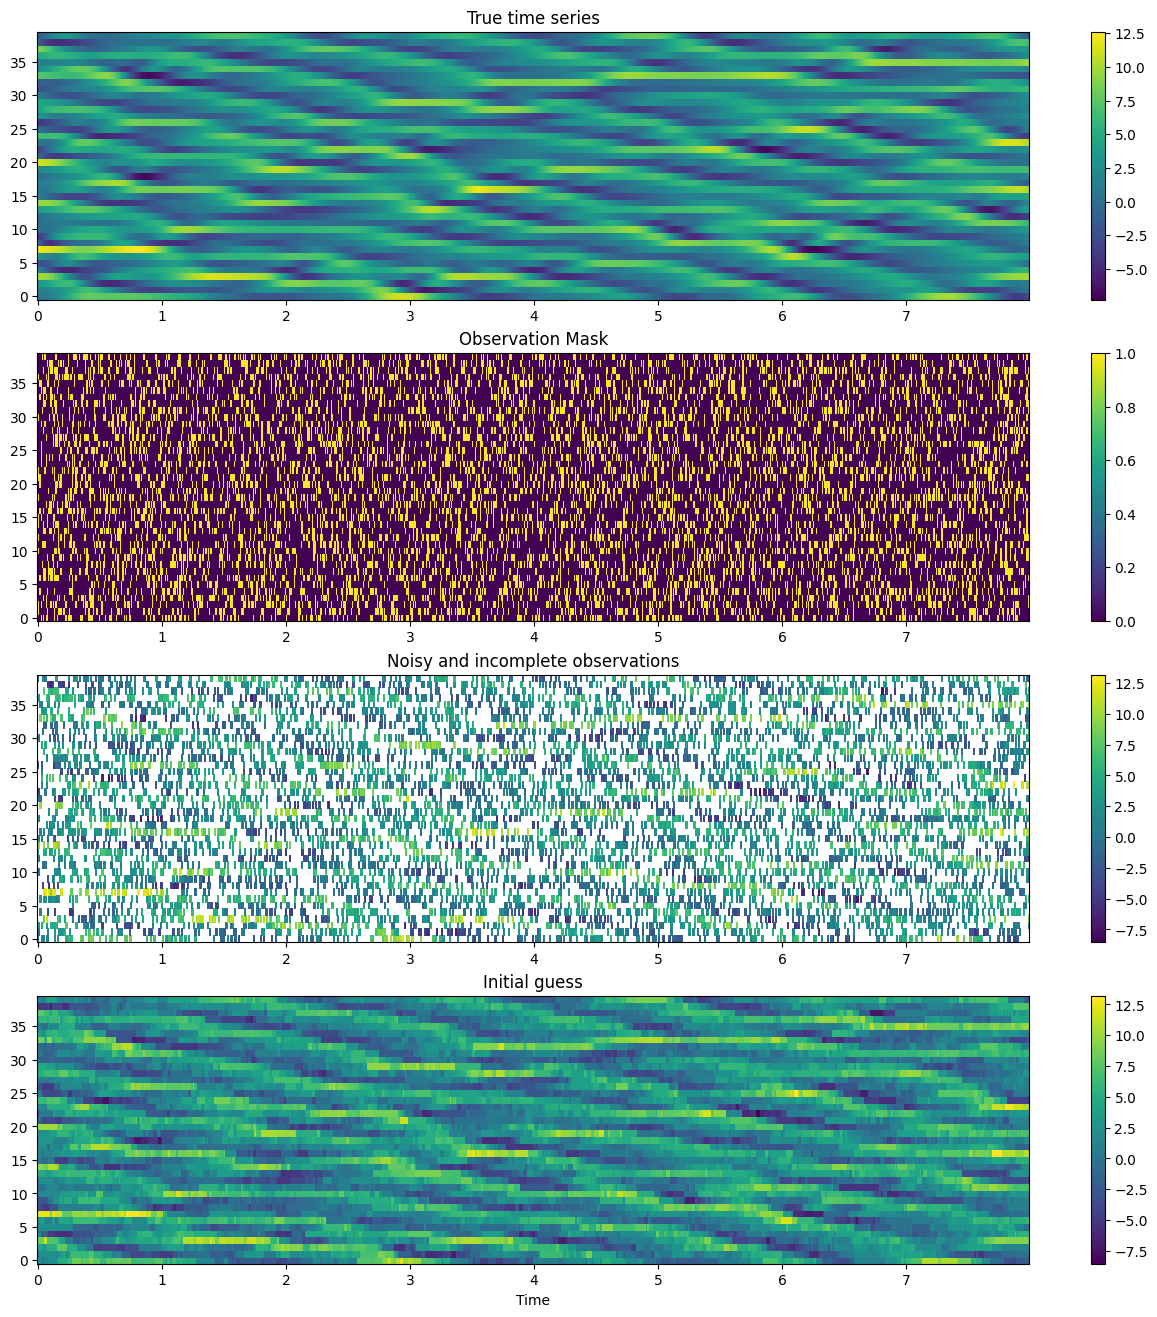

In [14]:
# we build an initial guess for the initial state, using the available observations
# We simply use the first available observation for each channel
initialization = naive_initialization(observations)  # state estimate for all time points

fig, ax = plt.subplots(4, 1, figsize=(16,16))

show_1dseqimg(true_ts.fields['x'][0].T, dt=time_step, ax=ax[0], title="True time series")
show_1dseqimg(observations.mask.fields['x'][0].T, dt=time_step, ax=ax[1], title="Observation Mask")
show_1dseqimg(valid_obs, dt=time_step, ax=ax[2], title="Noisy and incomplete observations")
show_1dseqimg(initialization.fields['x'][0].T, dt=time_step, ax=ax[3], title="Initial guess", x_label="Time")

We define the distribution on model errors.

In [15]:
n_steps = true_ts.time_axis.nelement()

model_error_distribs = DiagonalGaussian(torch.zeros(1, n_steps - 1, n_variables), 
                                        torch.ones(1, n_steps - 1, n_variables))

In [16]:
t0 = time()
assimilated_states = wc4dvar_single_window(next_step_function, 
                                          observations, 
                                          obs_op, 
                                          model_error_distribs,
                                          x_init=initialization, 
                                          optimizer_pars={'lr': 1},
                                          alpha=1e4,
                                          n_steps=50,
                                          verbose=0)                                       
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

assimilated_states = assimilated_states.detach()

Total time for the 4D-Var optimization: 19.762853860855103 seconds


Here we display the assimilated initial state of the trajectory and compare it to the initialization of the 4D-Var optimization.

Initial guess MSE: 2.3627355098724365
Assimilated state MSE: 0.15746067464351654


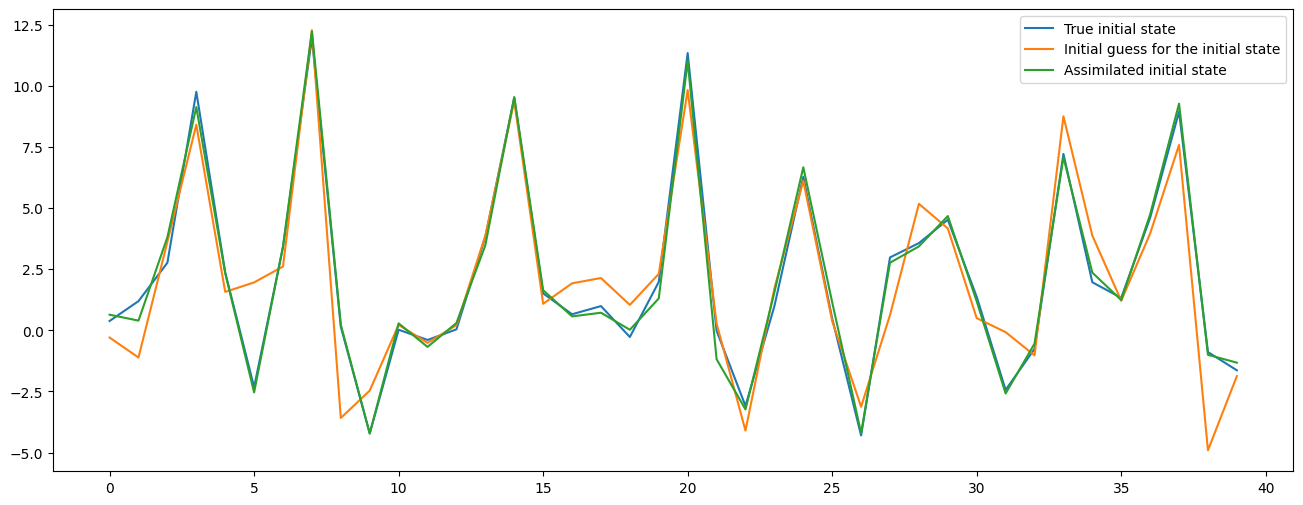

In [17]:
assimilated_initial_state = assimilated_states.fields['x'][0,0]

plt.figure(figsize=(16,6))
plt.plot(true_initial_state, label='True initial state')
plt.plot(initialization.fields['x'][0,0], label='Initial guess for the initial state')
plt.plot(assimilated_states.fields['x'][0,0], label='Assimilated initial state')
plt.legend()

MSE0 = torch.mean((initialization.fields['x'][0,0] - true_initial_state) **2)
MSE = torch.mean((assimilated_states.fields['x'][0,0] - true_initial_state) **2)

print(f'Initial guess MSE: {MSE0}')
print(f'Assimilated state MSE: {MSE}')

Let us now visualise the full assimilated trajectory and its difference to the groundtruth.

torch.Size([800, 40])


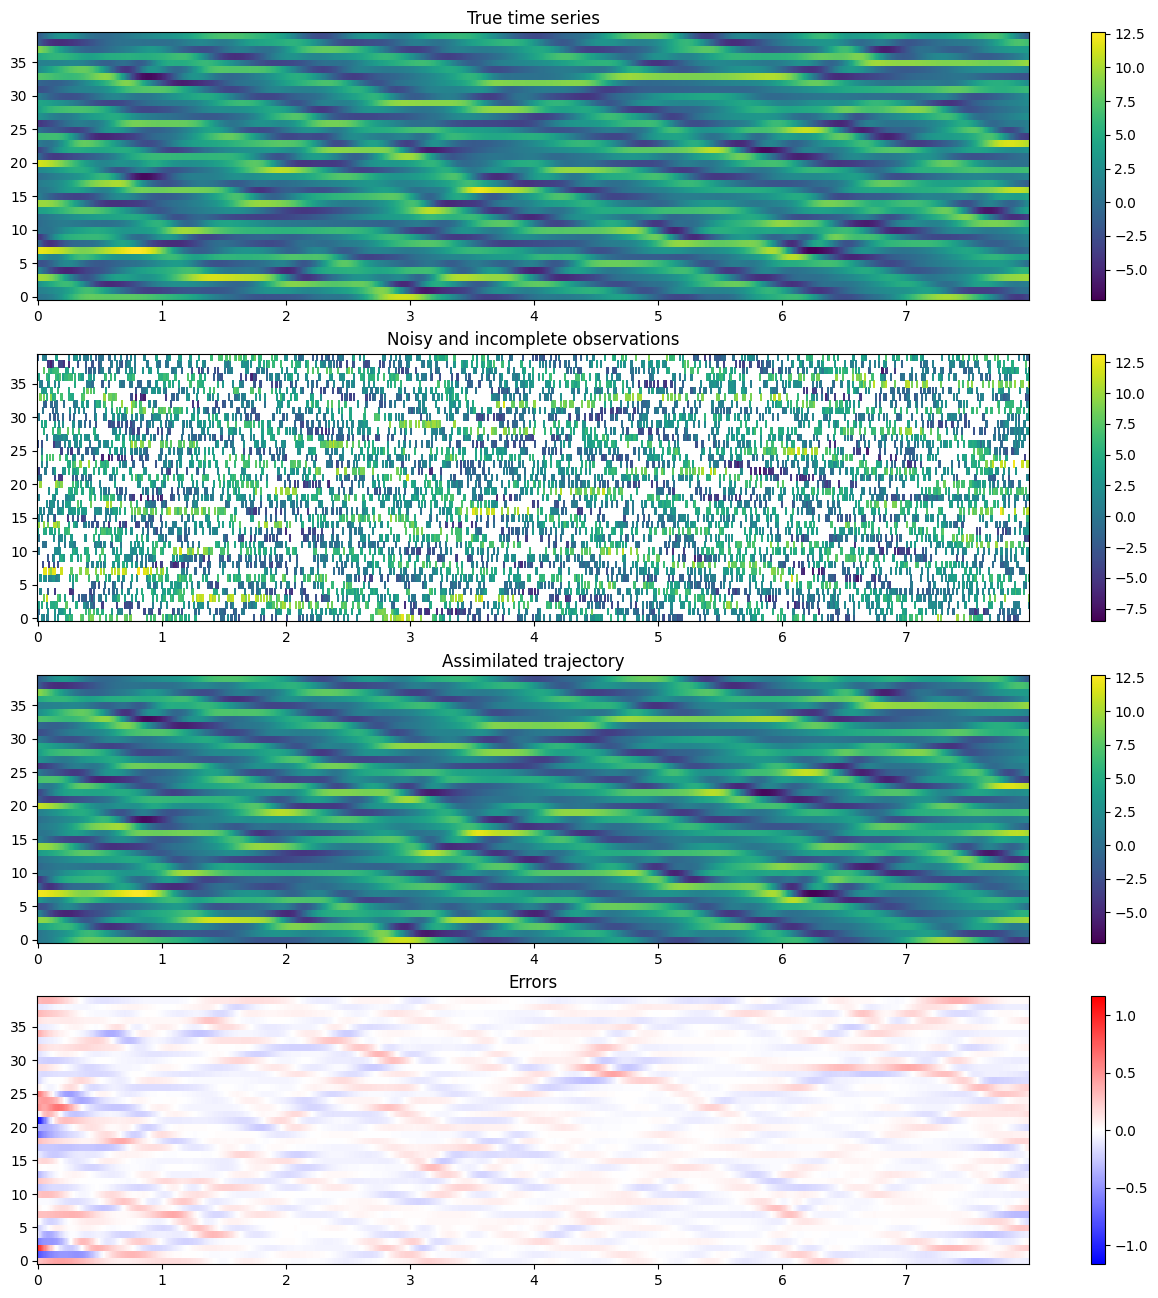

In [18]:
errors = (assimilated_states - true_ts).fields['x'][0]
print(errors.shape)
vmax_abs = torch.max(torch.abs(errors))

fig, ax = plt.subplots(4, 1, figsize=(16,16))
show_1dseqimg(true_ts.fields['x'][0].T, dt=time_step, ax=ax[0], title="True time series")
show_1dseqimg(valid_obs, dt=time_step, ax=ax[1], title="Noisy and incomplete observations")
show_1dseqimg(assimilated_states.fields['x'][0].T, dt=time_step, ax=ax[2], title="Assimilated trajectory")
show_1dseqimg(errors.T, dt=time_step, ax=ax[3], title="Errors", cmap="bwr", center_on_zero=True)

Finally one can see that the RMSE is higher on the edges of the assimilation window than in the middle.

torch.Size([800])


Text(0, 0.5, 'RMSE')

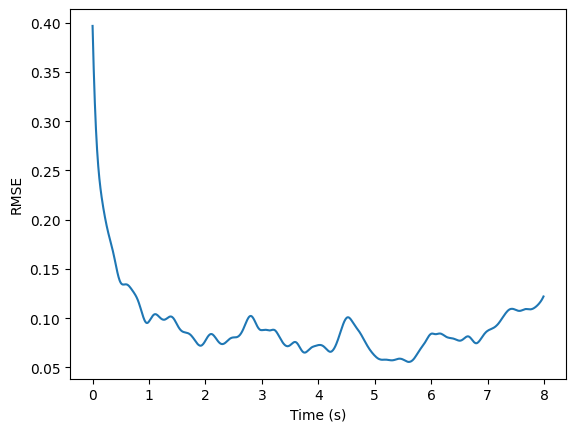

In [19]:
RMSE_over_time = torch.sqrt((errors ** 2).mean(dim=1))

print(RMSE_over_time.shape)

fig, ax = plt.subplots()
plt.plot(true_ts.time_axis, RMSE_over_time)
ax.set_xlabel('Time (s)')
ax.set_ylabel('RMSE')